In [1]:
!git clone https://github.com/hzxie/Pix2Vox.git


Cloning into 'Pix2Vox'...
remote: Enumerating objects: 809, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 809 (delta 2), reused 2 (delta 2), pack-reused 805 (from 2)
Receiving objects: 100% (809/809), 1.22 MiB | 14.36 MiB/s, done.
Resolving deltas: 100% (507/507), done.


In [10]:
%cd Pix2Vox

/content/Pix2Vox


In [15]:
!pip install open3d

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 98.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.0/228.0 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 74.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 64.0 MB/s eta 0:00:00
  Attempting uninstall: widgetsnbextension
    Found existing installation: widgetsnbextension 3.6.10
    Uninstalling widgetsnbextension-3.6.10:
      Successfully uninstalled widgetsnbextension-3.6.10
  Attempting uninstall: werkzeug
    Found existing installation: Werkzeug 3.1.3
    Uninstalling Werkzeug-3.1.3:
      Successfully uninstalled Werkzeug-3.1.3
  Attempting uninstall: flask
    Found existing installation: Flask 3.1.0
    Unins

In [1]:
import torch
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import sys
import os

In [2]:
os.getcwd()

'/content'

In [3]:
sys.path.append(os.getcwd())

In [4]:
sys.path.append(os.path.join(os.getcwd(), 'models'))

In [5]:
sys.path.append(os.path.join(os.getcwd(), 'core'))

In [6]:
pretrained_model_path = "/content/drive/MyDrive/Pix2Vox-A-ShapeNet.pth"

In [7]:
assert os.path.exists(pretrained_model_path)

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pretrained_model_path = "/content/drive/MyDrive/Pix2Vox-A-ShapeNet.pth"
checkpoint = torch.load(pretrained_model_path, map_location=device)
print(checkpoint.keys())

<ipython-input-8-689dba4ea31d>:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(pretrained_model_path, map_location=device)


dict_keys(['epoch_idx', 'best_iou', 'best_epoch', 'encoder_state_dict', 'decoder_state_dict', 'refiner_state_dict', 'merger_state_dict'])


In [11]:
from config import cfg

Saving old_and_new_city_landscape.jpg to old_and_new_city_landscape.jpg
Upload Done >>>> input_images/old_and_new_city_landscape.jpg
Files in input directory: ['DUBNOBEDSIDETABLE_2.jpg', 'light.jpg', 'old_and_new_city_landscape.jpg', '51dkx5orDKL._AC_SL1438_.jpg', '61WMMJ+VWJL._AC_SL1500_.jpg', 'bed01.webp']
Using device: cpu


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning:

The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning:

Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_BN_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_BN_Weights.DEFAULT` to get the most up-to-date weights.

<ipython-input-29-6ee07cc8d6a9>:39: FutureWarning:

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the def

Encoder loaded successfully.
Decoder loaded successfully.
Merger loaded successfully.
Refiner loaded successfully.
Tensor shape before unsqueeze: torch.Size([3, 224, 224])
Final input tensor shape: torch.Size([1, 1, 3, 224, 224])
Shape of feature tensor: torch.Size([1, 1, 256, 8, 8])
Shape of coarse_volumes: torch.Size([1, 1, 9, 32, 32, 32])
Shape of raw_feature: torch.Size([1, 1, 32, 32, 32])
Shape of merged volume: torch.Size([1, 32, 32, 32])
Shape of refined volume: torch.Size([1, 32, 32, 32])
Max value in refined_volume: 1.0
Min value in refined_volume: 3.626669797807125e-11


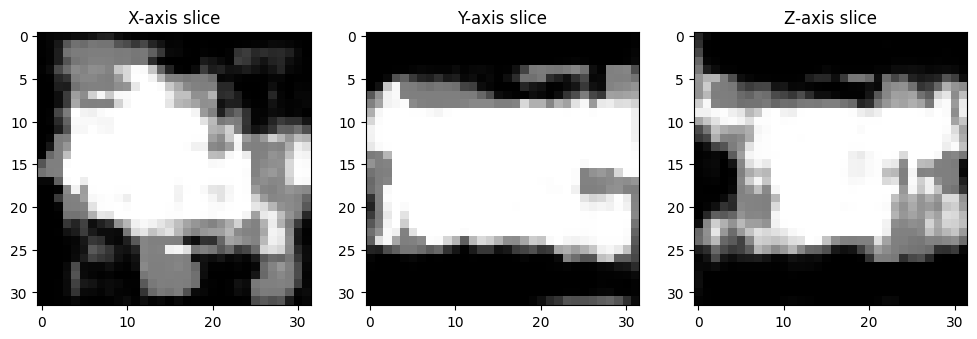

In [29]:
# ---------------------- مرحله ۱: بارگذاری تصویر ----------------------
from google.colab import files
import shutil
import os

input_dir = "input_images"
os.makedirs(input_dir, exist_ok=True)

uploaded = files.upload()

for filename in uploaded.keys():
    shutil.move(filename, os.path.join(input_dir, filename))

print("Upload Done >>>>", os.path.join(input_dir, list(uploaded.keys())[0]))
print("Files in input directory:", os.listdir(input_dir))

# ---------------------- مرحله ۲: بارگذاری مدل‌ها ----------------------
import torch
from PIL import Image
import torchvision.transforms as transforms
from models.encoder import Encoder
from models.decoder import Decoder
from models.merger import Merger
from models.refiner import Refiner

pretrained_model_path = "/content/drive/MyDrive/Pix2Vox-A-ShapeNet.pth"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# مقداردهی اولیه مدل‌ها
encoder = Encoder(cfg).to(device)
decoder = Decoder(cfg).to(device)
merger = Merger(cfg).to(device)
refiner = Refiner(cfg).to(device)

# بارگذاری وزن‌های از پیش‌آموزش‌داده‌شده
# در صورت نیاز می‌توانید از پارامتر weights_only=True استفاده کنید.
checkpoint = torch.load(pretrained_model_path, map_location=device)

# اصلاح بارگذاری encoder با حذف "module." از کلیدها
encoder_state_dict = {}
for key, value in checkpoint['encoder_state_dict'].items():
    new_key = key.replace("module.", "")
    encoder_state_dict[new_key] = value

encoder.load_state_dict(encoder_state_dict, strict=False)
print("Encoder loaded successfully.")

# اصلاح بارگذاری decoder به همین شیوه
decoder_state_dict = {}
for key, value in checkpoint['decoder_state_dict'].items():
    new_key = key.replace("module.", "")
    decoder_state_dict[new_key] = value

decoder.load_state_dict(decoder_state_dict, strict=False)
print("Decoder loaded successfully.")

# در صورت نیاز، اگر weight های merger و refiner هم دارای پیشوند "module." هستند:
merger_state_dict = {}
for key, value in checkpoint['merger_state_dict'].items():
    new_key = key.replace("module.", "")
    merger_state_dict[new_key] = value
merger.load_state_dict(merger_state_dict, strict=False)
print("Merger loaded successfully.")

refiner_state_dict = {}
for key, value in checkpoint['refiner_state_dict'].items():
    new_key = key.replace("module.", "")
    refiner_state_dict[new_key] = value
refiner.load_state_dict(refiner_state_dict, strict=False)
print("Refiner loaded successfully.")

# تنظیم مدل‌ها روی حالت ارزیابی
encoder.eval()
decoder.eval()
merger.eval()
refiner.eval()

# ---------------------- مرحله ۳: پردازش تصویر ----------------------
image_path = os.path.join(input_dir, list(uploaded.keys())[0])

try:
    image = Image.open(image_path).convert("RGB")
    image.show()  # نمایش تصویر برای بررسی صحت بارگذاری
except Exception as e:
    print("Error opening image:", e)

# تعریف تبدیلات
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

input_tensor = transform(image)
print("Tensor shape before unsqueeze:", input_tensor.shape)  # انتظار: [3, 224, 224]

# اضافه کردن batch dimension (تنها یک unsqueeze کافی است)
input_tensor = input_tensor.unsqueeze(0).unsqueeze(1).to(device)
print("Final input tensor shape:", input_tensor.shape)  # انتظار: [1, 3, 224, 224]

# ---------------------- مرحله ۴: عبور از مدل ----------------------
with torch.no_grad():
    feature = encoder(input_tensor)
    print("Shape of feature tensor:", feature.shape)

    coarse_volumes, raw_feature = decoder(feature)
    if isinstance(coarse_volumes, tuple):
        cv_shape = coarse_volumes[0].shape
    else:
        cv_shape = coarse_volumes.shape
    print("Shape of coarse_volumes:", cv_shape)
    print("Shape of raw_feature:", raw_feature.shape)

    merged_volume = merger(coarse_volumes, raw_feature)
    print("Shape of merged volume:", merged_volume.shape)

    refined_volume = refiner(merged_volume)
    print("Shape of refined volume:", refined_volume.shape)

print("Max value in refined_volume:", refined_volume.max().item())
print("Min value in refined_volume:", refined_volume.min().item())

# ---------------------- مرحله ۵: نمایش  ----------------------
import matplotlib.pyplot as plt
import numpy as np

volume_np = refined_volume.squeeze().cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# نمایش برش میانی در محورهای مختلف
axes[0].imshow(volume_np[volume_np.shape[0] // 2, :, :], cmap='gray')
axes[0].set_title("X-axis slice")
axes[1].imshow(volume_np[:, volume_np.shape[1] // 2, :], cmap='gray')
axes[1].set_title("Y-axis slice")
axes[2].imshow(volume_np[:, :, volume_np.shape[2] // 2], cmap='gray')
axes[2].set_title("Z-axis slice")

plt.show()


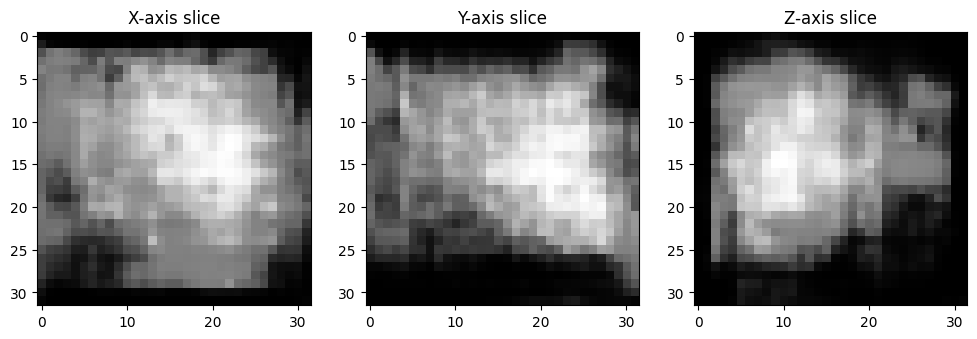

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# فرض بر این است که refined_volume به صورت torch tensor با ابعاد [1, 32, 32, 32] است
volume_np = refined_volume.squeeze().cpu().numpy()  # تبدیل به numpy array

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(volume_np[volume_np.shape[0] // 2, :, :], cmap='gray')
axes[0].set_title("X-axis slice")
axes[1].imshow(volume_np[:, volume_np.shape[1] // 2, :], cmap='gray')
axes[1].set_title("Y-axis slice")
axes[2].imshow(volume_np[:, :, volume_np.shape[2] // 2], cmap='gray')
axes[2].set_title("Z-axis slice")
plt.show()


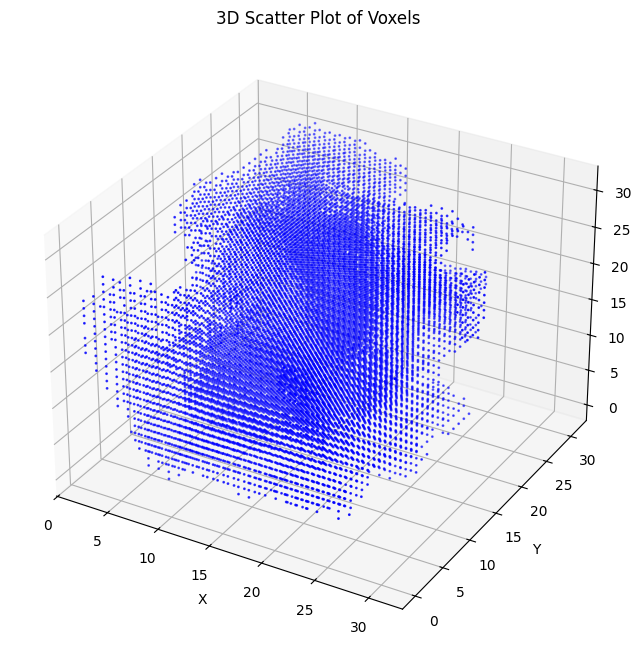

In [31]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # لازم است
import numpy as np

# استخراج نقاط فعال (voxel هایی که مقدارشان > threshold است)
threshold = 0.3
volume_np = refined_volume.squeeze().cpu().numpy()
x, y, z = np.where(volume_np > threshold)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x, y, z, c='blue', marker='o', s=1)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title("3D Scatter Plot of Voxels")
plt.show()


# **Interactive Visualization**

In [32]:
import plotly.graph_objects as go
import numpy as np

# استخراج نقاط فعال
threshold = 0.5
volume_np = refined_volume.squeeze().cpu().numpy()
x, y, z = np.where(volume_np > threshold)

fig = go.Figure(data=[go.Scatter3d(
    x=x, y=y, z=z,
    mode='markers',
    marker=dict(
        size=2,
        color=z,
        colorscale='Viridis',
        opacity=0.8
    )
)])

fig.update_layout(
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z'
    ),
    title="Interactive 3D Scatter Plot of Voxels"
)
fig.show()
